# Assignment 06

Use the World Bank Indicators dataset to answer the following questions. **Make sure to explain why you chose the statistical test and interpret the results! ** Include only data for 2020 in your analysis. Complete the tests in both Python and R. (Note that you may get errors in importing excel if you don't have the proper packages installed. You should install openpyxl in python and readxl in R if you haven't done so already.)

Make sure to be thorough in your analysis and explanation!

Please compile all results within this ipynb and turn the document on Blackboard.

## 1. Determine if there is a statistical difference between the **Regions** and **GDP per Capita**. Make sure to explain and interpret the results of the output

### R

Hint: For R You'll want to run this:

```R
install.packages('readxl')
library(dplyr)
library(readxl)
```

And use `readxl::read_excel('WDIEXCEL.xlsx')` to read the excel file.

In [ ]:
!pip install rpy2
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages("readxl")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/readxl_1.4.5.tar.gz'
Content type 'application/x-gzip' length 1636512 bytes (1.6 MB)
downloaded 1.6 MB


The downloaded source packages are in
	‘/tmp/RtmpZ7o1Vi/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘vctrs’

trying URL 'https://cran.rstudio.com/src/contrib/vctrs_0.7.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.0.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpZ7o1Vi/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.2.tar.gz'
Content type 'application/x-gzip' length 6358661 bytes (6.1 MB)
downloaded 6.1 MB


The downloaded source packages are in
	‘/tmp/RtmpZ7o1Vi/downloaded_packages’


In [ ]:
%%R
library(dplyr)
library(readxl)
library(ggplot2)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Read Excel File

In [ ]:
%%R
wdi <- readxl::read_excel('WDIEXCEL.xlsx')
wdi

# A tibble: 395,808 × 68
   `Country Name` `Country Code` `Indicator Name` `Indicator Code` `1960` `1961`
   <chr>          <chr>          <chr>            <chr>             <dbl>  <dbl>
 1 Africa Easter… AFE            Access to clean… EG.CFT.ACCS.ZS       NA     NA
 2 Africa Easter… AFE            Access to clean… EG.CFT.ACCS.RU.…     NA     NA
 3 Africa Easter… AFE            Access to clean… EG.CFT.ACCS.UR.…     NA     NA
 4 Africa Easter… AFE            Access to elect… EG.ELC.ACCS.ZS       NA     NA
 5 Africa Easter… AFE            Access to elect… EG.ELC.ACCS.RU.…     NA     NA
 6 Africa Easter… AFE            Access to elect… EG.ELC.ACCS.UR.…     NA     NA
 7 Africa Easter… AFE            Account ownersh… FX.OWN.TOTL.ZS       NA     NA
 8 Africa Easter… AFE            Account ownersh… FX.OWN.TOTL.FE.…     NA     NA
 9 Africa Easter… AFE            Account ownersh… FX.OWN.TOTL.MA.…     NA     NA
10 Africa Easter… AFE            Account ownersh… FX.OWN.TOTL.OL.…     NA     NA
# ℹ

List Columns Name

In [ ]:
%%R
colnames(wdi)

 [1] "Country Name"   "Country Code"   "Indicator Name" "Indicator Code"
 [5] "1960"           "1961"           "1962"           "1963"          
 [9] "1964"           "1965"           "1966"           "1967"          
[13] "1968"           "1969"           "1970"           "1971"          
[17] "1972"           "1973"           "1974"           "1975"          
[21] "1976"           "1977"           "1978"           "1979"          
[25] "1980"           "1981"           "1982"           "1983"          
[29] "1984"           "1985"           "1986"           "1987"          
[33] "1988"           "1989"           "1990"           "1991"          
[37] "1992"           "1993"           "1994"           "1995"          
[41] "1996"           "1997"           "1998"           "1999"          
[45] "2000"           "2001"           "2002"           "2003"          
[49] "2004"           "2005"           "2006"           "2007"          
[53] "2008"           "2009"           "2010"      

Find the GDP for 2020 with with the Country Name that we will connect later.

In [ ]:
%%R
gdp_2020 <- wdi %>%
  filter(`Indicator Name` == "GDP per capita (current US$)") %>%
  select(`Country Name`, `Country Code`, `2020`) %>%
  rename(GDP_per_capita = `2020`)
gdp_2020

# A tibble: 266 × 3
   `Country Name`                              `Country Code` GDP_per_capita
   <chr>                                       <chr>                   <dbl>
 1 Africa Eastern and Southern                 AFE                     1356.
 2 Africa Western and Central                  AFW                     1688.
 3 Arab World                                  ARB                     5736.
 4 Caribbean small states                      CSS                    10102.
 5 Central Europe and the Baltics              CEB                    16303.
 6 Early-demographic dividend                  EAR                     3254.
 7 East Asia & Pacific                         EAS                    11488.
 8 East Asia & Pacific (excluding high income) EAP                     8263.
 9 East Asia & Pacific (IDA & IBRD countries)  TEA                     8355.
10 Euro area                                   EMU                    37915.
# ℹ 256 more rows
# ℹ Use `print(n = ...)` to see more r

Let's Read the Regions File to merge it with the same connections.

In [ ]:
%%R
regions <- read.csv("Regions.csv")

head(regions)
colnames(regions)

 [1] "name"                     "alpha.2"                 
 [3] "alpha.3"                  "country.code"            
 [5] "iso_3166.2"               "region"                  
 [7] "sub.region"               "intermediate.region"     
 [9] "region.code"              "sub.region.code"         
[11] "intermediate.region.code"


Change Regions country code to a character to permit the merge.

In [ ]:
%%R
regions$country.code <- as.character(regions$country.code)

In [ ]:
%%R
# Make sure alpha.3 is character
regions$alpha.3 <- as.character(regions$alpha.3)

gdp_region_2020 <- gdp_2020 %>%
  left_join(regions, by = c("Country Code" = "alpha.3")) %>%
  filter(!is.na(region), !is.na(GDP_per_capita)) #--Take the Columns with NA off.
gdp_region_2020

# A tibble: 208 × 13
   `Country Name`      `Country Code` GDP_per_capita name   alpha.2 country.code
   <chr>               <chr>                   <dbl> <chr>  <chr>   <chr>       
 1 Afghanistan         AFG                      512. Afgha… AF      4           
 2 Albania             ALB                     5343. Alban… AL      8           
 3 Algeria             DZA                     3794. Alger… DZ      12          
 4 American Samoa      ASM                    15610. Ameri… AS      16          
 5 Andorra             AND                    37207. Andor… AD      20          
 6 Angola              AGO                     1451. Angola AO      24          
 7 Antigua and Barbuda ATG                    15225. Antig… AG      28          
 8 Argentina           ARG                     8501. Argen… AR      32          
 9 Armenia             ARM                     4506. Armen… AM      51          
10 Aruba               ABW                    24008. Aruba  AW      533         
# ℹ 198

Sum of the values merged in region for the table.

In [ ]:
%%R
table(gdp_region_2020$region)


  Africa Americas     Asia   Europe  Oceania 
      52       43       49       45       19 


Anova Section to see the connections between the Gdp and the region.

In [ ]:
%%R
anova <- aov(GDP_per_capita ~ region, data = gdp_region_2020)

In [ ]:
%%R
summary(anova)

             Df    Sum Sq   Mean Sq F value   Pr(>F)    
region        4 3.637e+10 9.094e+09   17.57 2.14e-12 ***
Residuals   203 1.051e+11 5.177e+08                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


I have chosen the anova test to examine the relationship between GDP per capita and infant mortality in 2020 because it gives me the best option to compare our variable the GDP in 2020 across the different independent groups which were the world regions. There the goal is to determine if there is a difference between those two groups in the GDP for our selcted year.

The regression results show a statistically significant difference between GDP per capita and infant mortality.
**Overall, the analysis demonstrates that GDP per capita is not evenly distributed across world regions, and that meaningful economic disparities exist across the worl for this year.**

### Python

Hint: To read the excel file, you'll want to install `openpyxl`. Do this by running `!pip install openpyxl`.

Hint: If you are replicating the Anova in the lecture.

In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load WDI data
wdi = pd.read_excel("WDIEXCEL.xlsx", engine="openpyxl")

# Load regions
regions = pd.read_csv("Regions.csv")


In [ ]:
gdp_2020 = (
    wdi[wdi["Indicator Name"] == "GDP per capita (current US$)"]
    [["Country Name", "Country Code", "2020"]]
    .rename(columns={"2020": "GDP_per_capita"}) )

In [ ]:
gdp_region_2020 = gdp_2020.merge(
    regions[["alpha-3", "region"]],
    left_on="Country Code",
    right_on="alpha-3",
    how="left"
).dropna(subset=["region", "GDP_per_capita"])

In [ ]:
model = smf.ols("GDP_per_capita ~ C(region)", data=gdp_region_2020).fit()
anova = sm.stats.anova_lm(model, typ=2)
anova

,sum_sq,df,F,PR(>F)
C(region),3.637426e+10,4.0,17.565507,2.142831e-12
Residual,1.050920e+11,203.0,NaN,NaN


# 2. Describe and show the relationship between **GDP per Capita** and **Infant Mortality Rate**

For extra, optional fun, try fitting a log transformation too. What's the interpretation of that regression line?

#### R

Print Unique names from the Table for the Name indicators

In [ ]:
%%R
unique(wdi$`Indicator Name`)


   [1] "Access to clean fuels and technologies for cooking (% of population)"                                                                         
   [2] "Access to clean fuels and technologies for cooking, rural (% of rural population)"                                                            
   [3] "Access to clean fuels and technologies for cooking, urban (% of urban population)"                                                            
   [4] "Access to electricity (% of population)"                                                                                                      
   [5] "Access to electricity, rural (% of rural population)"                                                                                         
   [6] "Access to electricity, urban (% of urban population)"                                                                                         
   [7] "Account ownership at a financial institution or with a mobile-money-service provider (

Read the files and select and filter depednign on our parts etc.

In [ ]:
%%R
library(stringr)
wdi <- readxl::read_excel("WDIEXCEL.xlsx", sheet = "Data")

gdp_2020 <- wdi %>%
  filter(str_detect(`Indicator Name`, "GDP per capita")) %>%
  select(`Country Name`, `Country Code`, `2020`) %>%
  rename(GDP_per_capita = `2020`)

infant_2020 <- wdi %>%
  filter(`Indicator Name` == "Mortality rate, infant (per 1,000 live births)") %>%
  select(`Country Name`, `Country Code`, `2020`) %>%
  rename(Infant_mortality = `2020`)



In [ ]:
Head of Infant Table

In [ ]:
%%R
nrow(gdp_2020)
head(infant_2020)

# A tibble: 6 × 3
  `Country Name`                 `Country Code` Infant_mortality
  <chr>                          <chr>                     <dbl>
1 Africa Eastern and Southern    AFE                       42.9 
2 Africa Western and Central     AFW                       62.2 
3 Arab World                     ARB                       25.0 
4 Caribbean small states         CSS                       16.8 
5 Central Europe and the Baltics CEB                        3.98
6 Early-demographic dividend     EAR                       27.5 


Merge the Data

In [ ]:
%%R
regression_data <- gdp_2020 %>%
  inner_join(infant_2020, by = c("Country Name", "Country Code")) %>%
  filter(!is.na(GDP_per_capita), !is.na(Infant_mortality))

In [ ]:
%%R
nrow(regression_data)
head(regression_data)

# A tibble: 6 × 4
  `Country Name`              `Country Code` GDP_per_capita Infant_mortality
  <chr>                       <chr>                   <dbl>            <dbl>
1 Africa Eastern and Southern AFE                   1405.               42.9
2 Africa Eastern and Southern AFE                   1356.               42.9
3 Africa Eastern and Southern AFE                     -5.32             42.9
4 Africa Eastern and Southern AFE                   3919.               42.9
5 Africa Eastern and Southern AFE                   3667.               42.9
6 Africa Western and Central  AFW                   1776.               62.2


Plot the data to see the relationship between those two variables.

`geom_smooth()` using formula = 'y ~ x'


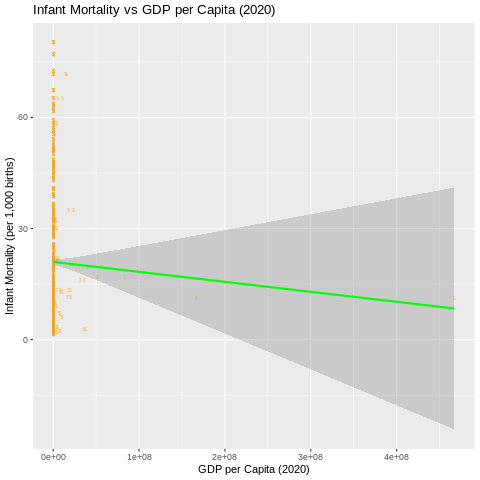

In [ ]:
%%R
library(ggplot2)

ggplot(regression_data, aes(x = GDP_per_capita, y = Infant_mortality)) +
  geom_point(shape = "$", alpha = 0.6, color = "orange") +
  geom_smooth(method = "lm", color = "green") +
  labs(
    title = "Infant Mortality vs GDP per Capita (2020)",
    x = "GDP per Capita (2020)",
    y = "Infant Mortality (per 1,000 births)"
  )

Linear Model with Infant Mortality as Y and GDP as x

In [ ]:
%%R
model <- lm(Infant_mortality ~ GDP_per_capita, data = regression_data)
summary(model)


Call:
lm(formula = Infant_mortality ~ GDP_per_capita, data = regression_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-19.595 -15.493  -6.795  11.105  59.305 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     2.099e+01  4.684e-01  44.821   <2e-16 ***
GDP_per_capita -2.696e-08  3.570e-08  -0.755     0.45    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 18.49 on 1563 degrees of freedom
Multiple R-squared:  0.0003646,	Adjusted R-squared:  -0.000275 
F-statistic:  0.57 on 1 and 1563 DF,  p-value: 0.4504



**Write Down Formula from Values etc**

#### Python

In [ ]:
infant_2020 = (
    wdi[wdi["Indicator Name"] == "Mortality rate, infant (per 1,000 live births)"]
    [["Country Name", "Country Code", "2020"]]
    .rename(columns={"2020": "Infant_mortality"})
)
infant_2020

,Country Name,Country Code,Infant_mortality
804,Africa Eastern and Southern,AFE,42.858888
2292,Africa Western and Central,AFW,62.159863
3780,Arab World,ARB,25.014251
5268,Caribbean small states,CSS,16.818872
6756,Central Europe and the Baltics,CEB,3.984085
...,...,...,...
389172,Virgin Islands (U.S.),VIR,NaN
390660,West Bank and Gaza,PSE,13.200000
392148,"Yemen, Rep.",YEM,34.500000
393636,Zambia,ZMB,40.900000


In [ ]:
merged = gdp_2020.merge(
    infant_2020,
    on=["Country Name", "Country Code"],
    how="inner"
).dropna()

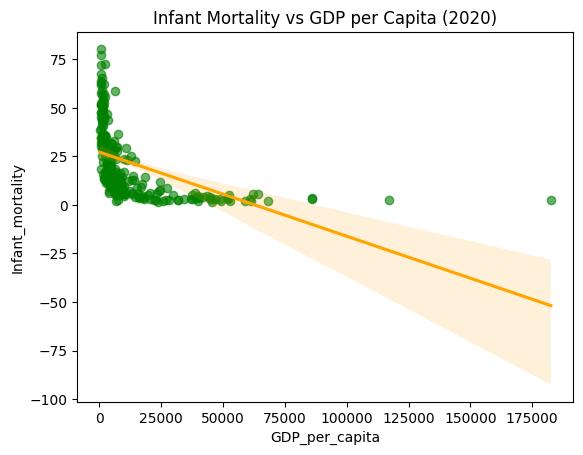

In [ ]:
sns.regplot(
    data=merged,
    x="GDP_per_capita",
    y="Infant_mortality",
    scatter_kws={"alpha": 0.6, "color":"green"},
    line_kws={"color": "orange"}
)
plt.title("Infant Mortality vs GDP per Capita (2020)")
plt.show()

In [ ]:
linear_model = smf.ols(
    "Infant_mortality ~ GDP_per_capita",
    data=merged
).fit()

linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Infant_mortality   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     75.53
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.03e-16
Time:                        00:14:34   Log-Likelihood:                -1002.4
No. Observations:                 239   AIC:                             2009.
Df Residuals:                     237   BIC:                             2016.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         27.1226      1.240     21.872      0.000      24.680      29.566
GDP_per_capita    -0.0004   4.98e-05     -8.691      0.000      -0.001      -0.000
==============================================================================
Omnibus:                       42.923   Durbin-Watson:                   1.803
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               60.065
Skew:                           1.161   Prob(JB):                     9.06e-14
Kurtosis:                       3.799   Cond. No.                     2.96e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.96e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The simple linear regression is what I selected here because we want to basically output the relationship of the independent and control variable. By using that we are able to make a line but also a linear model determining the slope and where it starts and how it can move on the graph etc.

The regression results show a statistically significant negative relationship between GDP per capita and infant mortality.

Infant_mortality = 20.99 - 0.00000002696 × GDP_per_capita

This means that countries with higher GDP per capita tend to have lower infant mortality rates. The negative slope of -0.00000002696 indicates that as income increases, infant mortality decreases.

The p‑value for GDP per capita is statistically significant, confirming that the relationship is not due to chance but to the real relation between the produces.
The R² value of 0.242 indicates that GDP per capita explains about 25% of the variation in infant mortality across countries.

**Overall, the model supports the idea that economic development is strongly associated with better health outcomes for infants and longer life.**